# DANDI:001936 NWB Tutorial: Social behavior mapping in autism-model rat lines via multi-camera 3D pose tracking

This notebook demonstrates how to read and visualize the Olveczky Lab social behavior
dataset (Klibaite et al. 2025), published in NWB format on the DANDI Archive as
[DANDI:001936](https://dandiarchive.org/dandiset/001936).

Two rats are placed together in an arena and recorded with a **6-camera video system**.
3D body pose is tracked for each rat with **sDANNCE** (23 keypoints), and pairwise
body-contact **events** between the two rats are derived from the resulting 3D meshes.
Each NWB file corresponds to **one rat's perspective** of a two-rat social session and
contains:

- `acquisition` — 6 `ImageSeries` (one per camera), pointing to the raw video files
- `processing/behavior/PoseEstimationSDANNCE` — 23 `PoseEstimationSeries` (one per body
  keypoint) giving 3D (x, y, z) trajectories for this rat
- `processing/behavior/Skeletons` — the keypoint graph (nodes + edges) used for pose
  estimation
- `events/SkinContacts` — an `EventsTable` of pairwise body-part contacts between the
  two rats

The notebook has two ways to get an `nwbfile` to work with — pick whichever fits your
workflow:

1. **Stream directly from DANDI** — no download needed, works anywhere.
2. **Read a local NWB file** — fastest if you already have the file on disk (e.g. from
   the lab's data share), and lets us also open the companion video files.

Everything after that (file structure exploration and visualizations) works the same
regardless of which source you used.


## Setup

```bash
pip install dandi pynwb remfile h5py ndx-pose matplotlib pandas opencv-python-headless
```


In [31]:
# Core data manipulation and analysis
from pathlib import Path

import h5py

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import remfile
from dandi.dandiapi import DandiAPIClient

# NWB and DANDI access
from pynwb import NWBHDF5IO
from pynwb.image import ImageSeries

# Configure matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# ndx-pose register the extension types used by this dataset with pynwb
# on import — they don't need to be called directly, just imported.
import ndx_pose  # noqa: F401

## Data Access Functions

## 1. Stream a session directly from DANDI

DANDI assets can be read directly over HTTP with [`remfile`](https://github.com/flatironinstitute/remfile),
without downloading the file to disk. This is the easiest way to explore the dataset if
you don't already have it locally.

We'll stream one session from **[DANDI:001936](https://dandiarchive.org/dandiset/001936)**.
Swap `dandiset_id` / `file_path` for any other subject/session in the Dandiset — use
`dandiset.get_assets()` to list them all.


In [32]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality):
    """
    Load NWB file from DANDI Archive via streaming.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_{modality}*.nwb"

    client = DandiAPIClient()
    client.dandi_authenticate()
    dandiset = client.get_dandiset(dandiset_id, "draft")
    assets = dandiset.get_assets_by_glob(pattern=pattern, order="path")

    s3_urls = []
    for asset in assets:
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
        s3_urls.append(s3_url)

    if len(s3_urls) != 1:
        raise ValueError(f"Expected 1 file, found {len(s3_urls)} for pattern {pattern}")

    s3_url = s3_urls[0]

    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()

    # Videos in NWB are stored as ImageSeries with external_file containing relative paths
    # We resolve them to full DANDI asset paths and get S3 URLs for streaming

    nwb_parent = Path(asset.path).parent
    video_s3_urls = {}

    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            # Get the relative path and resolve to full DANDI path
            relative_path = obj.external_file[0]
            full_path = f"{nwb_parent}/{relative_path}"

            # Fetch the video asset and get its S3 URL. Keep the query string (strip_query=False):
            # while the dandiset is in draft, the blob store requires the signed URL it carries --
            # a stripped URL returns 403 (both for direct HTTP access and for cv2.VideoCapture).
            video_asset = dandiset.get_asset_by_path(full_path)
            if video_asset is not None:
                video_s3_urls[name] = video_asset.get_content_url(
                    follow_redirects=1, strip_query=False
                )

    return nwbfile, io, video_s3_urls

## 2. Read a local NWB file

If the file is already on disk (e.g. mounted from the lab's data share), reading it is
just a standard `NWBHDF5IO` call.

In [33]:
def load_nwb_local(directory_path, subject_id, session_id, modality):
    """
    Load NWB file from local directory.
    """
    directory_path = Path(directory_path)
    nwbfile_path = directory_path / f"sub-{subject_id}_ses-{session_id}_{modality}.nwb"

    if not nwbfile_path.exists():
        raise FileNotFoundError(f"NWB file not found: {nwbfile_path}")

    io = NWBHDF5IO(path=nwbfile_path, load_namespaces=True)
    nwbfile = io.read()

    video_file_paths = {}
    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            video_file_paths[name] = obj.external_file[0]
    return nwbfile, io, video_file_paths

### Choose which source to explore

In [34]:
# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files
dandiset_id = "001936"
subject_id = "ARID1B-M1"
session_id = "day-1-social-M1-M2-20221017"
modality = "image"
if USE_DANDI:
    nwbfile, io, video_s3_urls = load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality)
else:
    # Specify your local directory path
    local_directory = f"H:/{dandiset_id}/sub-{subject_id}"  # Replace with actual path
    nwbfile, io, video_file_paths = load_nwb_local(local_directory, subject_id, session_id, modality)

## 3. Explore the file structure


In [35]:
print("Session description:", nwbfile.session_description)
print("Session start time: ", nwbfile.session_start_time)
print()

subject = nwbfile.subject
print("Subject ID:  ", subject.subject_id)
print("Species:     ", subject.species)
print("Strain:      ", subject.strain)
print("Genotype:    ", subject.genotype)
print("Sex:         ", subject.sex)
print("Date of birth:", subject.date_of_birth)
print("Description: ", subject.description)


Session description: Social behavior experiment in the Olveczky Lab. Two rats of defined genotypes were placed together in an arena and their behavior was recorded with a six-camera system. 3D pose estimation was performed using sDANNCE. Cohort group: ARID1B, encounter round: SOC1, session: M1 (rat1) vs M2 (rat2).
Session start time:  2022-10-17 00:00:00+00:00

Subject ID:   ARID1B-M1
Species:      Rattus norvegicus
Strain:       LE-Arid1b-em1Mcwi
Genotype:     KO wt
Sex:          U
Date of birth: 2022-06-16 00:00:00+00:00
Description:  Rat M1 from cohort ARID1B. Marking: LB. Cage: 2. Mother: LEF0537. Supplier: Medical College of Wisconsin. RRID: RGD_14394518


In [36]:
print("acquisition:")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print()
print("processing modules:")
for module_name, module in nwbfile.processing.items():
    print(f"  {module_name}:")
    for name, obj in module.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")

print()
print("events:")
for name, obj in nwbfile.events.items():
    print(f"  {name}: {type(obj).__name__} ({len(obj)} rows)")


acquisition:
  VideoCamera1: ImageSeries
  VideoCamera2: ImageSeries
  VideoCamera3: ImageSeries
  VideoCamera4: ImageSeries
  VideoCamera5: ImageSeries
  VideoCamera6: ImageSeries

processing modules:
  behavior:
    PoseEstimationSDANNCE: MultiCameraPoseEstimation
    Skeletons: Skeletons

events:
  SkinContacts: EventsTable (5112209 rows)


## 4. Visualize each data stream

### 4a. Video acquisition (6 cameras)

Each `ImageSeries` in `acquisition` points to a raw `.mp4` file rather than storing
pixel data inside the NWB file (`format="external"`). This keeps the NWB file small.
Pixel frames aren't accessible through `remfile`/`h5py` (that only streams the NWB
file itself) — but `cv2.VideoCapture` can read frames directly from the video, whether
it's a local file or a DANDI-hosted URL (see section 4e for an example).

In [37]:
for i in range(1, 7):
    series = nwbfile.acquisition[f"VideoCamera{i}"]
    print(f"VideoCamera{i}: rate={series.rate:.2f} Hz")


VideoCamera1: rate=49.96 Hz
VideoCamera2: rate=49.96 Hz
VideoCamera3: rate=49.96 Hz
VideoCamera4: rate=49.96 Hz
VideoCamera5: rate=49.96 Hz
VideoCamera6: rate=49.96 Hz


In [38]:
if USE_DANDI:

    from IPython.display import HTML

    camera_to_display = "VideoCamera1"

    if camera_to_display in video_s3_urls:
        video_url = video_s3_urls[camera_to_display]
        display(HTML(f"""
        <video width="640" height="480" controls>
            <source src="{video_url}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
        <p><b>{camera_to_display}</b></p>
        """))
    else:
        print(f"{camera_to_display} not available for this session")

In [39]:
import cv2

if not USE_DANDI:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for i, ax in enumerate(axes.flat, start=1):
        cap = cv2.VideoCapture(video_file_paths[i])
        cap.set(cv2.CAP_PROP_POS_FRAMES, 1000)  # an arbitrary frame partway through
        success, frame = cap.read()
        cap.release()

        if success:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Camera {i}")
        ax.axis("off")
    fig.suptitle("Frame 1000 from each camera")
    fig.tight_layout()

### 4b. 3D pose estimation (sDANNCE)

`PoseEstimationSDANNCE` holds one `PoseEstimationSeries` per body keypoint, each an
`(n_frames, 3)` array of (x, y, z) coordinates in millimeters, sampled at ~50 Hz.


In [40]:
pose_estimation = nwbfile.processing["behavior"]["PoseEstimationSDANNCE"]

keypoints = list(pose_estimation.pose_estimation_series.keys())
print(f"{len(keypoints)} keypoints:")
print(keypoints)


23 keypoints:
['PoseEstimationSeriesAnklel', 'PoseEstimationSeriesAnkler', 'PoseEstimationSeriesEarl', 'PoseEstimationSeriesEarr', 'PoseEstimationSeriesElbowl', 'PoseEstimationSeriesElbowr', 'PoseEstimationSeriesFootl', 'PoseEstimationSeriesFootr', 'PoseEstimationSeriesHandl', 'PoseEstimationSeriesHandr', 'PoseEstimationSeriesHipl', 'PoseEstimationSeriesHipr', 'PoseEstimationSeriesKneel', 'PoseEstimationSeriesKneer', 'PoseEstimationSeriesShoulderl', 'PoseEstimationSeriesShoulderr', 'PoseEstimationSeriesSnout', 'PoseEstimationSeriesSpinef', 'PoseEstimationSeriesSpinel', 'PoseEstimationSeriesSpinem', 'PoseEstimationSeriesTailbase', 'PoseEstimationSeriesWristl', 'PoseEstimationSeriesWristr']


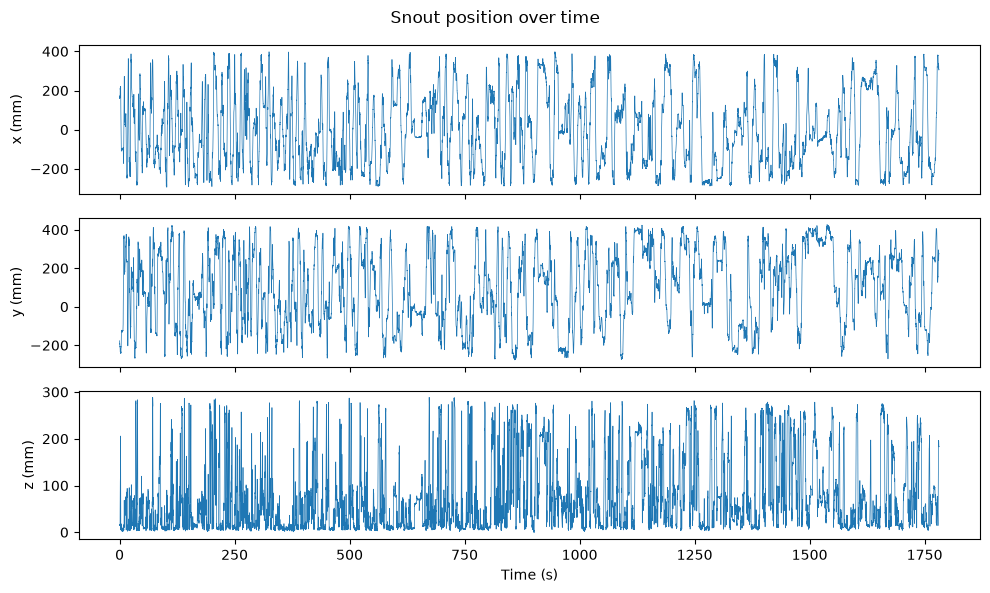

In [41]:
# XYZ trajectory of the snout over the whole session
snout = pose_estimation.pose_estimation_series["PoseEstimationSeriesSnout"]
snout_xyz = snout.data[:]
t = np.arange(snout_xyz.shape[0]) / snout.rate + snout.starting_time

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    ax.plot(t, snout_xyz[:, dim], linewidth=0.5)
    ax.set_ylabel(f"{label} (mm)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Snout position over time")
fig.tight_layout()


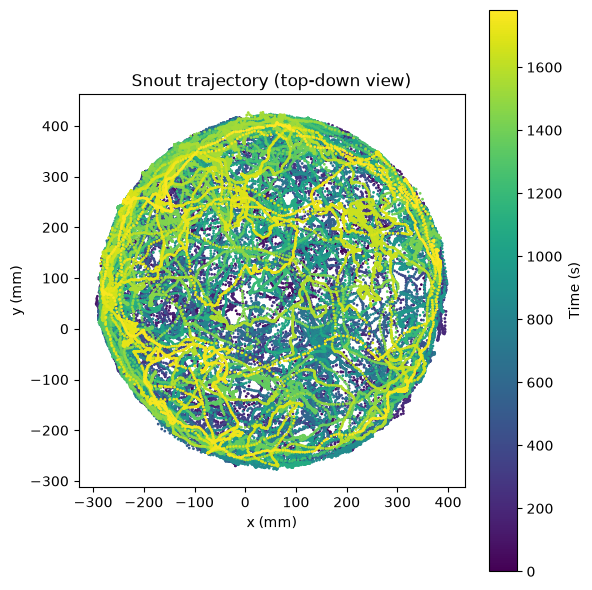

In [42]:
# Top-down (x, y) trajectory, colored by time
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(snout_xyz[:, 0], snout_xyz[:, 1], c=t, cmap="viridis", s=1)
fig.colorbar(sc, ax=ax, label="Time (s)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Snout trajectory (top-down view)")
fig.tight_layout()


### 4c. Skeleton definition + a single pose frame

`Skeletons` describes the keypoint graph (nodes + edges) used for pose estimation. We
can combine it with the per-keypoint data above to draw the full 3D pose at a single
frame.


In [43]:
skeletons = nwbfile.processing["behavior"]["Skeletons"].skeletons
skeleton = skeletons["SkeletonPoseEstimationSDANNCE_Rat1"]

nodes = skeleton.nodes[:]
edges = skeleton.edges[:]
print(f"{len(nodes)} nodes, {len(edges)} edges")
print(nodes)


23 nodes, 23 edges
['Snout' 'EarL' 'EarR' 'SpineF' 'SpineM' 'SpineL' 'TailBase' 'ShoulderL'
 'ElbowL' 'WristL' 'HandL' 'ShoulderR' 'ElbowR' 'WristR' 'HandR' 'HipL'
 'KneeL' 'AnkleL' 'FootL' 'HipR' 'KneeR' 'AnkleR' 'FootR']


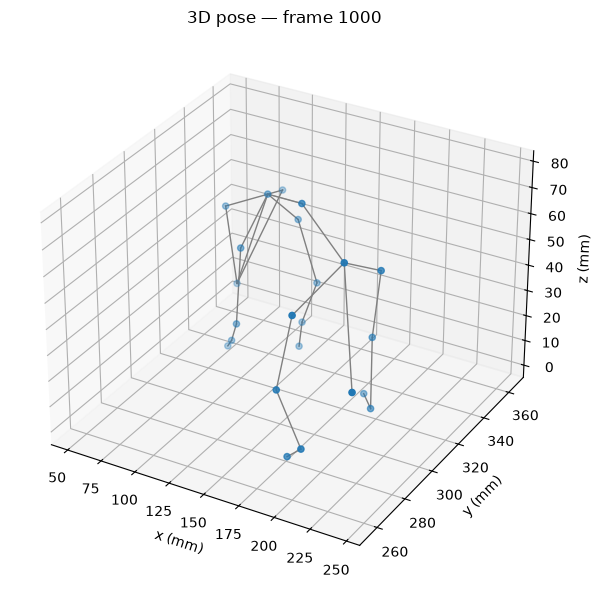

In [44]:
frame_idx = 1000

# gather (x, y, z) for every keypoint at this frame, in `nodes` order
coords = np.array(
    [pose_estimation.pose_estimation_series[f"PoseEstimationSeries{node.capitalize()}"].data[frame_idx]
     for node in nodes]
)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color="tab:blue", s=20)
for node_i, node_j in edges:
    xs, ys, zs = coords[[node_i, node_j]].T
    ax.plot(xs, ys, zs, color="gray", linewidth=1)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose — frame {frame_idx}")
fig.tight_layout()


### 4d. Pose keypoints overlaid on a video frame

Each of the 6 cameras is geometrically calibrated: `nwbfile.devices` holds one
`ndx_pose.CalibratedCamera` per camera (`intrinsic_matrix`, `rotation_matrix`,
`translation_vector`, `distortion_coefficients`), and the same `CalibratedCamera` is linked
both from that camera's `ImageSeries` in `acquisition` (via `.device`) and from its
per-camera entry in `PoseEstimationSDANNCE`. That means the 3D keypoints (millimeters,
world coordinates) can be projected into any camera's 2D pixel space with
`cv2.projectPoints`, and drawn directly on top of the video frame they were estimated from.

We reuse the single-frame 3D pose (`coords`, `edges`) computed in section 4c above.
`cv2.VideoCapture` can read frames from either a local video file or the DANDI streaming
URL, so this works with both data-source options from section 1/2.

In [45]:
def project_points(points_3d, camera):
    """Project (n, 3) world-space points (mm) into a CalibratedCamera's 2D pixel coordinates.

    DANNCE calibration matrices are stored in MATLAB's row-vector convention
    (``x_cam = x_world @ r + t``, ``x_pixel ~ x_cam @ K``), which is the transpose of the
    column-vector convention OpenCV's `cv2.projectPoints` expects -- hence transposing
    `rotation_matrix`/`intrinsic_matrix` below.
    """
    rotation_vector, _ = cv2.Rodrigues(np.asarray(camera.rotation_matrix).T)
    translation_vector = np.asarray(camera.translation_vector)
    intrinsic_matrix = np.asarray(camera.intrinsic_matrix).T
    distortion_coefficients = (
        np.asarray(camera.distortion_coefficients) if camera.distortion_coefficients is not None else None
    )
    points_2d, _ = cv2.projectPoints(
        points_3d, rotation_vector, translation_vector, intrinsic_matrix, distortion_coefficients
    )
    return points_2d.reshape(-1, 2)

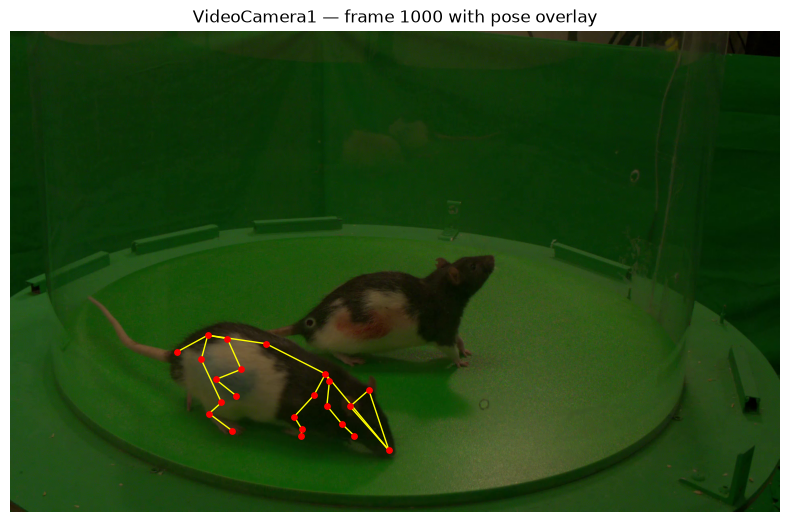

In [46]:
camera_to_display = "VideoCamera1"

video_source = video_s3_urls[camera_to_display] if USE_DANDI else str(
    Path(local_directory) / video_file_paths[camera_to_display]
)
camera_device = nwbfile.acquisition[camera_to_display].device

cap = cv2.VideoCapture(video_source)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # frame_idx set in section 4c, kept in sync with `coords`
success, frame = cap.read()
cap.release()

if success:
    points_2d = project_points(coords, camera_device)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    for node_i, node_j in edges:
        xs, ys = points_2d[[node_i, node_j]].T
        ax.plot(xs, ys, color="yellow", linewidth=1)
    ax.scatter(points_2d[:, 0], points_2d[:, 1], color="red", s=15, zorder=3)
    ax.set_title(f"{camera_to_display} — frame {frame_idx} with pose overlay")
    ax.axis("off")
    fig.tight_layout()
else:
    print(f"Could not read frame {frame_idx} from {camera_to_display} ({video_source})")

### 4e. Body-contact events between the two rats

`events/SkinContacts` records each moment the two rats' 3D body meshes touch, labeled
by which body parts were involved (e.g. `"right foot x left toe"`).


In [ ]:
skin_contacts = nwbfile.events["SkinContacts"]
contacts_df = skin_contacts.to_dataframe()
contacts_df.head()


In [ ]:
top_contacts = contacts_df["event_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_contacts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of events")
ax.set_title("Most common body-contact types")
fig.tight_layout()


In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(contacts_df["timestamp"], np.zeros(len(contacts_df)), "|", markersize=8, alpha=0.3)
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_title(f"Skin-contact event timeline ({len(contacts_df)} events)")
fig.tight_layout()


## Summary

This notebook showed how to:

- Stream an NWB file directly from DANDI (no download) or read one from a local path
- Inspect a session's subject metadata, acquisition, processing modules, and events
- Visualize the 6-camera video acquisition
- Plot 3D pose trajectories and a full skeleton pose from sDANNCE tracking
- Project 3D pose keypoints into a camera's 2D pixel space using its calibration, and
  overlay them on a video frame
- Explore pairwise body-contact events between the two rats

### Further resources

- [PyNWB documentation](https://pynwb.readthedocs.io/)
- [NWB overview](https://www.nwb.org/)
- [DANDI Archive documentation](https://www.dandiarchive.org/handbook/)
- [ndx-pose extension](https://github.com/rly/ndx-pose)
- [ndx-events extension](https://github.com/rly/ndx-events)